# 🏠 Family Expense Analytics

## Objective

The objective of this project is to analyze household expense data to identify spending patterns, payment preferences, monthly trends, and provide actionable recommendations for better financial planning.

---

### Dataset

- 500 transactions
- 4 family members
- 6 spending categories
- 3 payment modes
- Jan–Jun 2026

# Table of Contents

1. Import Libraries
2. Load Dataset
3. Data Inspection
4. Descriptive Statistics
5. Category Analysis
6. Member Analysis
7. Payment Mode Analysis
8. Date Analysis
9. Distribution Analysis
10. Key Business Insights
11. Recommendations
12. Conclusion

In [7]:
with open ("expenses.csv" , "r") as f : 
    expense_data = f.read()

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt 

df = pd.read_csv("expenses.csv")

In [14]:
df

,member_name,category,amount,date,payment_mode
0,Mother,Food,539,2026-05-24,UPI
1,Mother,Shopping,382,2026-06-19,Card
2,Utkarsh,Food,2661,2026-06-06,UPI
3,Mother,Shopping,1785,2026-03-23,Card
4,Father,Bills,2883,2026-03-20,UPI
...,...,...,...,...,...
495,Utkarsh,Entertainment,1696,2026-05-12,UPI
496,Sister,Food,2487,2026-03-11,Cash
497,Mother,Food,2551,2026-03-16,Card
498,Mother,Food,2436,2026-01-02,Card


### CATEGORY ANALYSIS

In [17]:
shape = df.shape
shape

(500, 5)

In [18]:
df.head(10)

,member_name,category,amount,date,payment_mode
0,Mother,Food,539,2026-05-24,UPI
1,Mother,Shopping,382,2026-06-19,Card
2,Utkarsh,Food,2661,2026-06-06,UPI
3,Mother,Shopping,1785,2026-03-23,Card
4,Father,Bills,2883,2026-03-20,UPI
5,Sister,Food,1494,2026-05-16,UPI
6,Mother,Food,1690,2026-06-19,Cash
7,Father,Food,798,2026-01-04,Cash
8,Sister,Food,2068,2026-04-13,UPI
9,Father,Bills,1979,2026-06-18,Card


In [19]:
df.tail(10)

,member_name,category,amount,date,payment_mode
490,Sister,Entertainment,1656,2026-03-10,UPI
491,Utkarsh,Entertainment,2476,2026-05-24,Cash
492,Sister,Shopping,443,2026-03-05,UPI
493,Father,Food,1094,2026-01-03,UPI
494,Mother,Food,2242,2026-01-21,Card
495,Utkarsh,Entertainment,1696,2026-05-12,UPI
496,Sister,Food,2487,2026-03-11,Cash
497,Mother,Food,2551,2026-03-16,Card
498,Mother,Food,2436,2026-01-02,Card
499,Sister,Food,1301,2026-05-29,Cash


In [20]:
df.columns

Index(['member_name', 'category', 'amount', 'date', 'payment_mode'], dtype='object')

In [24]:
df.dtypes

member_name     object
category        object
amount           int64
date            object
payment_mode    object
dtype: object

In [27]:
df.isnull().sum()

member_name     0
category        0
amount          0
date            0
payment_mode    0
dtype: int64

In [40]:
des = df["amount"].describe()
des

count     500.000000
mean     1520.352000
std       849.811494
min        52.000000
25%       783.500000
50%      1459.500000
75%      2243.250000
max      2999.000000
Name: amount, dtype: float64

## Category Analysis

### Business Question
Which expense categories contribute the most to household spending, and which categories should be prioritized for cost optimization?

In [43]:
total_spending = df["amount"].sum()
total_spending

np.int64(760176)

In [48]:
avg_amount = total_spending / len(df)
avg_amount

np.float64(1520.352)

In [50]:
highest_transaction = df["amount"].max()
highest_transaction

2999

In [51]:
lowest_transaction = df["amount"].min()
lowest_transaction

52

In [53]:
total_transaction = len(df)
total_transaction

500

In [15]:
total_spending_by_category = df.groupby('category')["amount"].sum() 
total_spending_by_category

category
Bills             83375
Entertainment     97251
Food             312204
Gym               65077
Shopping         166477
Travel            35792
Name: amount, dtype: int64

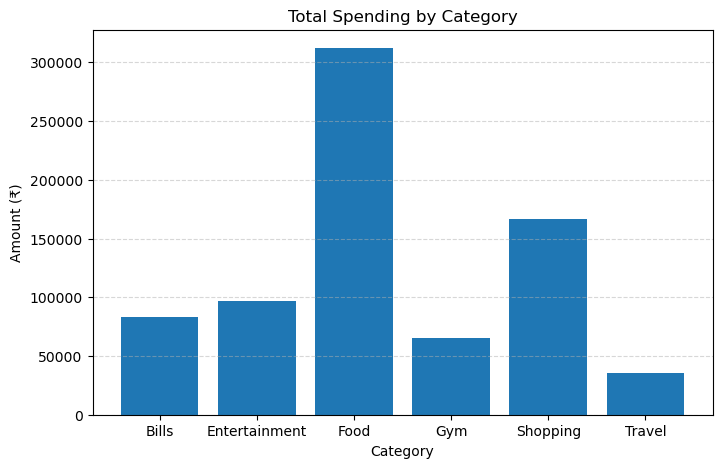

In [57]:
plt.figure(figsize=(8,5))

plt.bar(
    total_spending_by_category.index,
    total_spending_by_category.values
)

plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Observation

• Food contributes the highest household expenditure (₹312,204).

• Shopping is the second largest spending category.

• Travel has the lowest expenditure, suggesting fewer travel-related expenses.

• Food and Shopping together account for a significant portion of the family's total expenses.

In [19]:
highest_paying_category = df.groupby('category')["amount"].sum().sort_values(ascending = False)
highest_paying_category

category
Food             312204
Shopping         166477
Entertainment     97251
Bills             83375
Gym               65077
Travel            35792
Name: amount, dtype: int64

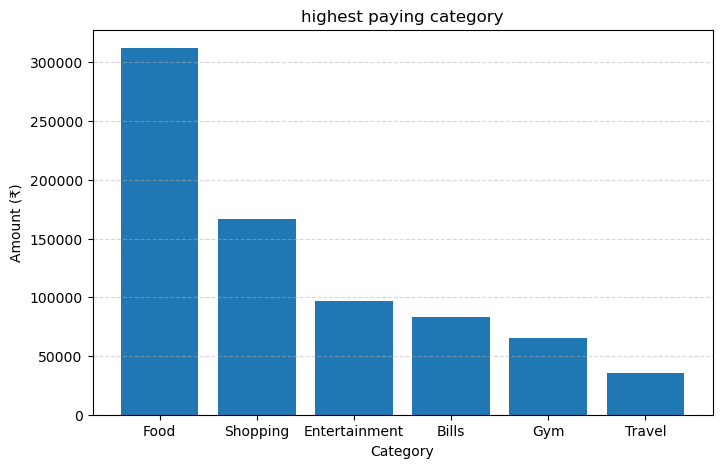

In [56]:
plt.figure(figsize=(8,5))

plt.bar(
    highest_paying_category.index,
    highest_paying_category.values
)

plt.title("highest paying category")
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [21]:
number_of_transaction = df["category"].value_counts()
number_of_transaction

category
Food             204
Shopping         111
Entertainment     58
Bills             57
Gym               45
Travel            25
Name: count, dtype: int64

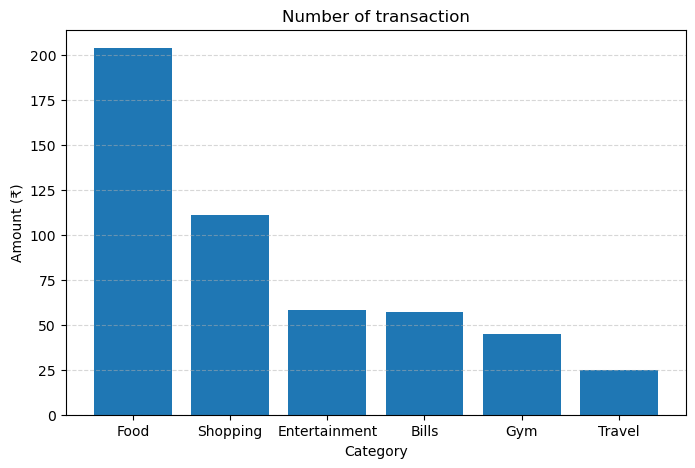

In [55]:
plt.figure(figsize=(8,5))

plt.bar(
    number_of_transaction.index,
    number_of_transaction.values
)

plt.title("Number of transaction")
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [23]:
avg_transaction = df.groupby('category')["amount"].mean().sort_values(ascending = False)
avg_transaction

category
Entertainment    1676.741379
Food             1530.411765
Shopping         1499.792793
Bills            1462.719298
Gym              1446.155556
Travel           1431.680000
Name: amount, dtype: float64

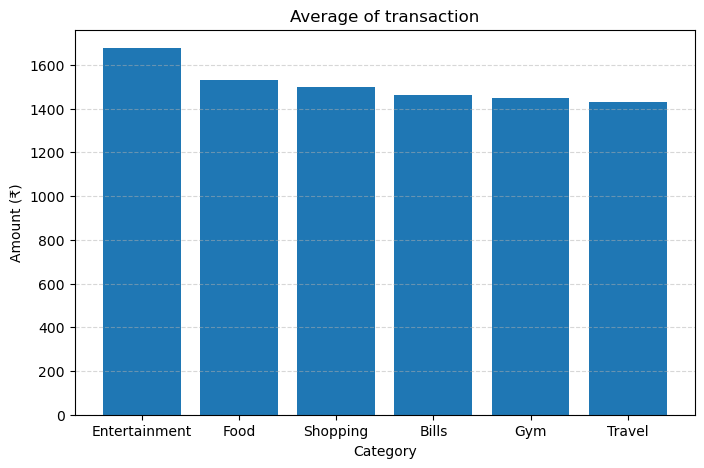

In [54]:
plt.figure(figsize=(8,5))

plt.bar(
    avg_transaction.index,
    avg_transaction.values
)

plt.title("Average of transaction")
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### OBSERVATION
Food accounts for the highest total expenditure (₹312,204), indicating it is the primary expense category for the family.

In [25]:
category_percentage = (
    df.groupby("category")["amount"]
      .sum()
)

category_percentage = (
    category_percentage / category_percentage.sum()
) * 100

category_percentage

category
Bills            10.967855
Entertainment    12.793222
Food             41.069963
Gym               8.560781
Shopping         21.899797
Travel            4.708383
Name: amount, dtype: float64

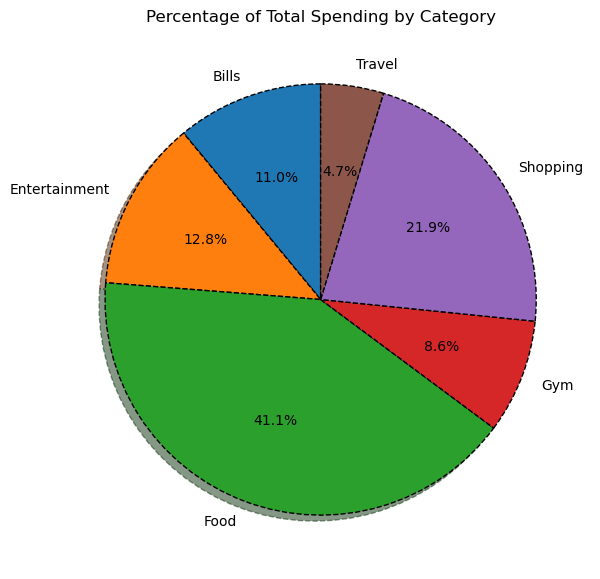

In [29]:
plt.figure(figsize=(7,7))

plt.pie(
    category_percentage,
    labels=category_percentage.index,
    autopct="%1.1f%%",
    startangle=90,
    shadow=True,
    wedgeprops = {
    "edgecolor": "black",
    "linestyle" : "--",
    
    }
)

plt.title("Percentage of Total Spending by Category")

plt.show()

## MEMBER ANALYSIS

🎯 Business Question

Which family member contributes the most to household expenses, and what are their spending patterns?

In [30]:
member_spending = df.groupby('member_name')["amount"].sum()
member_spending

member_name
Father     191799
Mother     229730
Sister     186079
Utkarsh    152568
Name: amount, dtype: int64

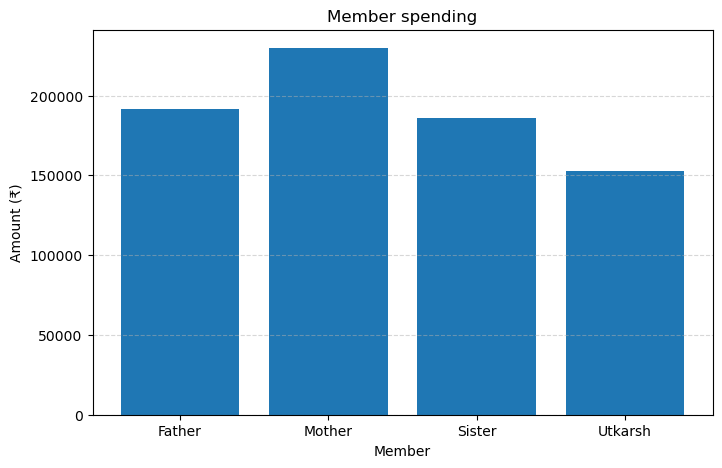

In [53]:
plt.figure(figsize=(8,5))

plt.bar(
    member_spending.index,
    member_spending.values
)

plt.title("Member spending")
plt.xlabel("Member")
plt.ylabel("Amount (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [32]:
avg_spending = df.groupby('member_name')["amount"].mean()
avg_spending

member_name
Father     1431.335821
Mother     1595.347222
Sister     1525.237705
Utkarsh    1525.680000
Name: amount, dtype: float64

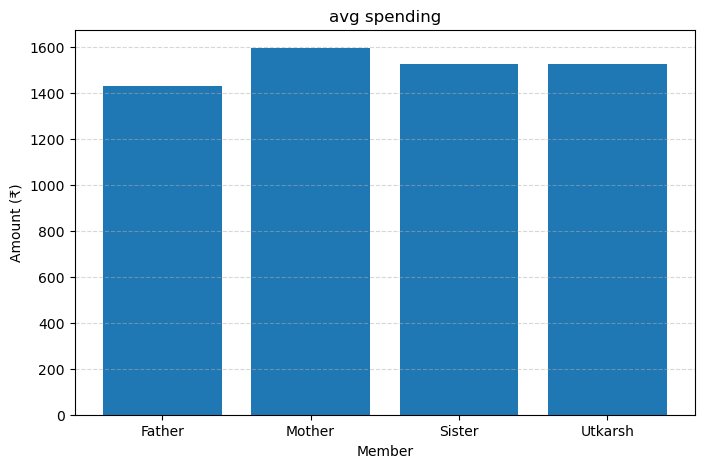

In [50]:
plt.figure(figsize=(8,5))

plt.bar(
    avg_spending.index,
    avg_spending.values
)

plt.title("avg spending")
plt.xlabel("Member")
plt.ylabel("Amount (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [34]:
transaction_count = df["member_name"].value_counts()
transaction_count

member_name
Mother     144
Father     134
Sister     122
Utkarsh    100
Name: count, dtype: int64

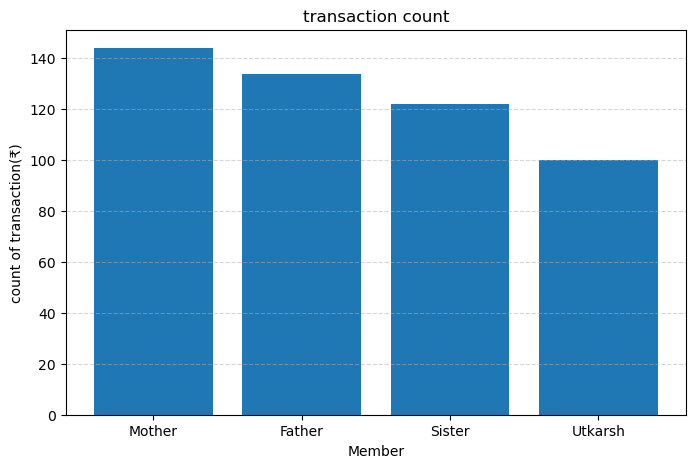

In [51]:
plt.figure(figsize=(8,5))

plt.bar(
    transaction_count.index,
    transaction_count.values
)

plt.title("transaction count")
plt.xlabel("Member")
plt.ylabel("count of transaction(₹)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [36]:
highest_spender = df.groupby('member_name')["amount"].sum().sort_values(ascending = False)
highest_spender

member_name
Mother     229730
Father     191799
Sister     186079
Utkarsh    152568
Name: amount, dtype: int64

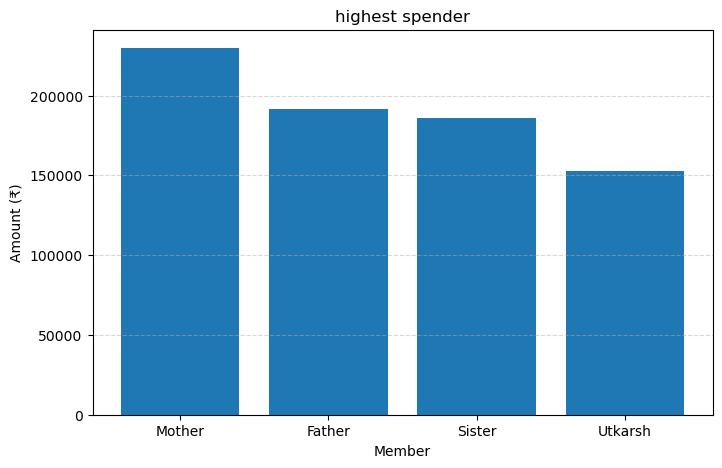

In [52]:
plt.figure(figsize=(8,5))

plt.bar(
    highest_spender.index,
    highest_spender.values
)

plt.title("highest spender")
plt.xlabel("Member")
plt.ylabel("Amount (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## observation 
Mother is the highest spender in the household, with a total expenditure of ₹229,730 across 144 transactions. This indicates that she is responsible for the largest share of household spending. Father is the second-highest spender with ₹191,799 across 134 transactions.

## Recommendation
Tracking food and shopping expenses separately could help identify opportunities to reduce recurring household costs.

## PAYMENT MODE ANALYSIS 

🎯 Business Question

Which payment method accounts for the highest total household expenditure?

In [38]:
PAYMENT_MODE_SPENDING = df.groupby('payment_mode')["amount"].sum()
PAYMENT_MODE_SPENDING

payment_mode
Card    253012
Cash    262960
UPI     244204
Name: amount, dtype: int64

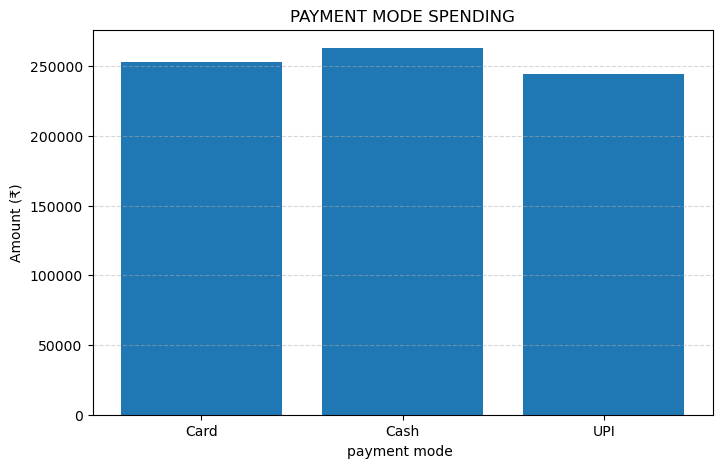

In [49]:
plt.figure(figsize=(8,5))

plt.bar(
    PAYMENT_MODE_SPENDING.index,
    PAYMENT_MODE_SPENDING.values
)

plt.title("PAYMENT MODE SPENDING")
plt.xlabel("payment mode ")
plt.ylabel("Amount (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [ ]:
no_transaction = df["payment_mode"].value_counts()
no_transaction

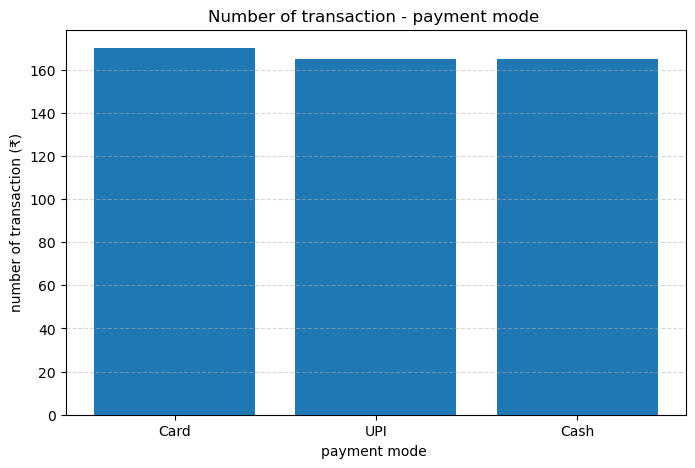

In [61]:
plt.figure(figsize=(8,5))

plt.bar(
    no_transaction.index,
    no_transaction.values
)

plt.title("Number of transaction - payment mode ")
plt.xlabel("payment mode ")
plt.ylabel("number of transaction (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [ ]:
avg_transaction = df.groupby('payment_mode')["amount"].mean()
avg_transaction

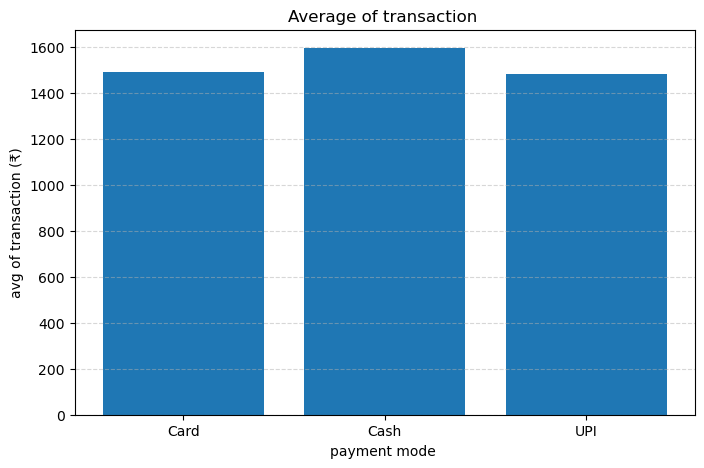

In [63]:
plt.figure(figsize=(8,5))

plt.bar(
    avg_transaction.index,
    avg_transaction.values
)

plt.title("Average of transaction ")
plt.xlabel("payment mode ")
plt.ylabel("avg of transaction (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## observation 
CARD PAYMENT IS DOMINATING IN THE HOUSE BUT UPI AND CASH ARE STILL ON SAME PAGE USED ON  BASIS REGULAR 

## summariztion using pivot table 

In [20]:
avg_spending = df.pivot_table(index = 'member_name' , columns = ['payment_mode' , 'category'] , values = 'amount', aggfunc = 'mean' , margins = True , fill_value=0)
avg_spending

payment_mode         Card                                          \
category            Bills Entertainment         Food          Gym   
member_name                                                         
Father        1423.352941      0.000000  1390.000000     0.000000   
Mother           0.000000      0.000000  1669.033333     0.000000   
Sister           0.000000   1487.214286  1245.076923     0.000000   
Utkarsh          0.000000   1969.000000  1445.100000  1236.785714   
All           1423.352941   1631.750000  1498.276923  1236.785714   

payment_mode                                   Cash                \
category         Shopping       Travel        Bills Entertainment   
member_name                                                         
Father           0.000000  1662.444444  1481.681818      0.000000   
Mother        1409.857143     0.000000     0.000000      0.000000   
Sister        1590.529412     0.000000     0.000000   1887.222222   
Utkarsh          0.000000     0.000000     0.000000   1650.555556   
All           1478.111111  1662.444444  1481.681818   1768.888889   

payment_mode                                                         UPI  \
category             Food          Gym     Shopping  Travel        Bills   
member_name                                                                
Father        1338.590909     0.000000     0.000000  1526.8  1476.722222   
Mother        1717.450000     0.000000  1733.782609     0.0     0.000000   
Sister        1478.642857     0.000000  1643.071429     0.0     0.000000   
Utkarsh       1569.307692  1719.444444     0.000000     0.0     0.000000   
All           1520.289855  1719.444444  1699.459459  1526.8  1476.722222   

payment_mode                                                              \
category     Entertainment         Food          Gym     Shopping Travel   
member_name                                                                
Father            0.000000  1472.388889     0.000000     0.000000  927.0   
Mother            0.000000  1709.633333     0.000000  1128.307692    0.0   
Sister         1725.846154  1374.500000     0.000000  1400.875000    0.0   
Utkarsh        1477.142857  1563.000000  1467.590909     0.000000    0.0   
All            1638.800000  1570.228571  1467.590909  1278.689655  927.0   

payment_mode          All  
category                   
member_name                
Father        1431.335821  
Mother        1595.347222  
Sister        1525.237705  
Utkarsh       1525.680000  
All           1520.352000

##📊 Pivot Table Analysis


Insight 1: Father's Spending Pattern

Father's highest average spending is on Travel using Cash (₹1,662.44), while his lowest average spending is on Travel using UPI (₹927.00). This suggests that higher-value travel expenses are generally paid in cash, whereas UPI is used for smaller travel transactions.

Insight 2: Mother's Spending Pattern

Mother primarily spends on Food and Shopping. Her highest average transaction is Shopping using Card (₹1,733.78), indicating that card payments are preferred for larger shopping purchases.

Insight 3: Sister's Spending Pattern

Sister has the highest average Entertainment expense using Card (₹1,887.22), suggesting entertainment purchases are relatively high-value and are commonly made using cards.

Insight 4: Utkarsh's Spending Pattern

Utkarsh records the highest average expense in Entertainment using Cash (₹1,969.00). Gym-related expenses are spread across multiple payment methods, indicating consistent spending on fitness.

Cross-Member Insights
Insight 5

Entertainment generally has higher average transaction values across multiple family members, indicating that entertainment purchases tend to be less frequent but more expensive.

Insight 6

Food expenses are common across all family members, but the average transaction amount remains relatively consistent (approximately ₹1,300–₹1,700), suggesting regular day-to-day spending rather than occasional large purchases.

Insight 7

Shopping expenses are concentrated mainly among Mother and Sister, indicating they account for most household shopping activities.

Insight 8

Travel expenses are almost entirely associated with Father, suggesting he is primarily responsible for transportation or travel-related costs.

Payment Behaviour
Insight 9

Card payments are associated with several of the highest average transaction amounts, particularly in Shopping and Entertainment, indicating that larger discretionary purchases are often made using cards.

Insight 10

Cash and UPI are used across multiple categories, but their average transaction values vary by family member, suggesting payment method preferences differ based on the type of expense.

Business Recommendation

Since Food and Shopping represent significant portions of household expenditure, implementing monthly budgets for these categories could help control recurring expenses. Additionally, tracking high-value Entertainment purchases may identify opportunities to reduce discretionary spending.

In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
df['month'] = df['date'].dt.month_name()

In [9]:
df.pivot_table(index = 'month' , columns = ['category', 'payment_mode'] , values = 'amount' , aggfunc = 'sum' , fill_value=0)

category     Bills             Entertainment                Food         \
payment_mode  Card  Cash   UPI          Card   Cash   UPI   Card   Cash   
month                                                                     
April         4402  8763  2165          3992   2090  6534  15341  17573   
February      3091  7875  5625          5326   3866  3274   6113  18998   
January        700  2670   828          1502   5009  5049  24416  14055   
June          5916  4823  7604         11724   8842  4716  15754  22337   
March         5002  1620  6170          5692   1550  7270  18707  22607   
May           5086  6846  4189          4399  10483  5933  17057   9330   

category              Gym              Shopping              Travel        \
payment_mode    UPI  Card  Cash    UPI     Card   Cash   UPI   Card  Cash   
month                                                                       
April         10430     0  2933  10024    16532  12879  7828    620  3586   
February      18918  4694  2925   3960    14741  10840  8166   3321  2220   
January       11122  1629   613   4635     3637   6126  7833      0  3875   
June          20201  2289  5378    987     9133   9607  5269   2415     0   
March         24743  4845     0   7015    13004  14096  6297   1553  4145   
May           24502  3858  3626   5666     9468   9332  1689   7053  1442   

category            
payment_mode   UPI  
month               
April            0  
February       353  
January          0  
June          2720  
March         1907  
May            582

## DISTRIBUTION ANALYSIS

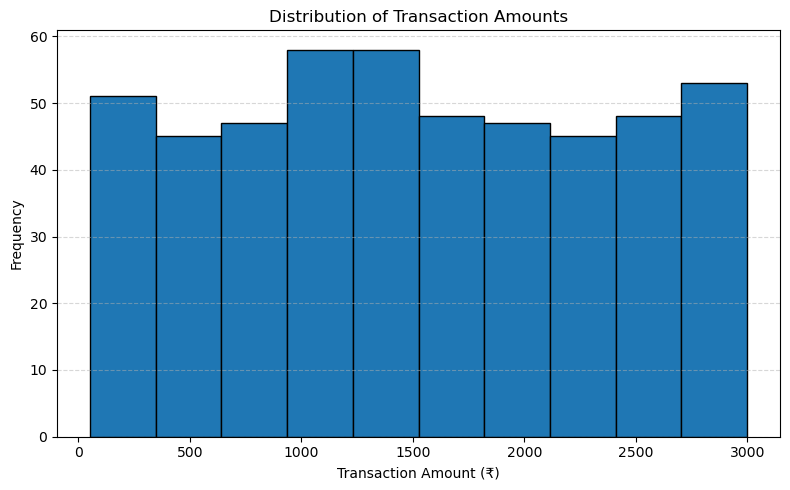

In [64]:
plt.figure(figsize=(8,5))

plt.hist(
    df["amount"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

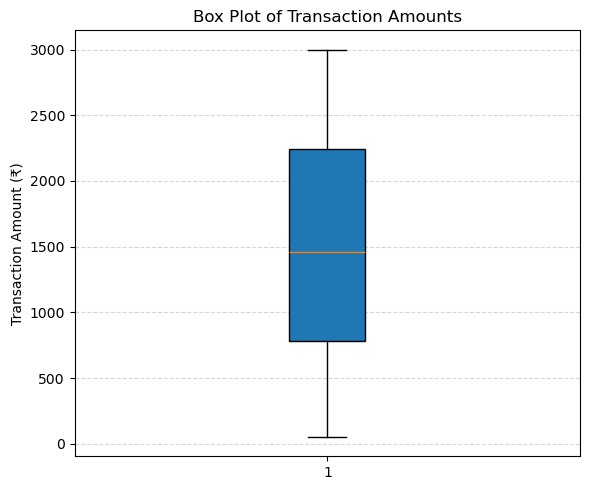

In [65]:
plt.figure(figsize=(6,5))

plt.boxplot(
    df["amount"],
    patch_artist=True
)

plt.title("Box Plot of Transaction Amounts")
plt.ylabel("Transaction Amount (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

📝 Business Question

Are there any unusually high or low transactions (outliers) in the household expense data?


### Business Insights

• The transaction amounts are fairly evenly distributed across the spending range.

• No significant outliers were detected, indicating a balanced distribution of expenses.

• Most transactions fall within the expected spending range without extreme values.

### Business Insights

• Household transaction amounts are distributed across the entire spending range rather than being concentrated in a single interval.

• The frequency of transactions remains relatively consistent from low-value to high-value purchases.

• This indicates that the synthetic dataset represents a balanced mix of small, medium, and large household expenses.

• No single transaction range dominates the spending behavior.

# Executive Summary

After analyzing 500 household expense transactions:

• Food contributes the highest overall expenditure.

• Mother accounts for the highest household spending.

• Card is the preferred payment method.

• Monthly expenses remain relatively stable.

• No major outliers were observed.

• Shopping and Food together account for over half of household expenses.

These insights can help the family allocate budgets more effectively.

# Conclusion

This project demonstrates the complete data analysis workflow from data generation to business insights.

Using Python, Pandas, and Matplotlib, household expense data was cleaned, explored, visualized, and analyzed to identify spending behavior and provide practical financial recommendations.

The project showcases data manipulation, exploratory data analysis, visualization, and business storytelling skills commonly used by Data Analysts.

### Note

This analysis is based on a synthetically generated dataset created for learning and demonstration purposes. Real household transaction patterns may exhibit different distributions and spending behaviors.